In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv


In [2]:
load_dotenv()

True

In [3]:
class SubState(TypedDict):
    
    input_text: str
    translated_text: str

In [6]:
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

subgraph_llm =  ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [7]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Nepali.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [8]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [9]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_nep: str
    

In [10]:
parent_llm = ChatGroq(model="llama-3.3-70b-versatile")

In [11]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}


In [12]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_nep': result['translated_text']}


In [13]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

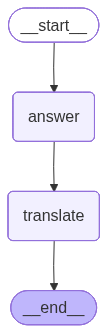

In [14]:
graph = parent_builder.compile()

graph

In [15]:
graph.invoke({'question': "what is the capital of Nepal?"})

{'question': 'what is the capital of Nepal?',
 'answer_eng': 'The capital of Nepal is Kathmandu.',
 'answer_nep': 'नेपालको राजधानी काठमाण्डु हो।'}

### here states are isolated and independent